# Tutorial 5 — Principal Component Analysis (PCA)
### BUAD 405 — Applied Econometrics | Summer '26

**Learning goal:** practise the logic of reducing many correlated variables into a few uncorrelated **components**, reading a **scree plot** to decide how many to keep, and interpreting **loadings** to name each component.

**Dataset:** Polish Companies Bankruptcy data (`polish_bankruptcy_clustering_unlabelled.csv`) — the same firm-level financial ratios you cleaned for the clustering tutorial. Variable names stay **X1–X64** as in the earlier handouts.

**Running example.** Throughout this notebook we will keep coming back to one imaginary firm, **Firm A**, and plug its numbers into every formula we introduce. This keeps the jargon anchored to something concrete instead of floating in the abstract.

| Ratio | Meaning | Firm A's value |
|---|---|---|
| X1 | net profit / total assets | 0.02 |
| X2 | total liabilities / total assets | 0.65 |
| X3 | working capital / total assets | 0.10 |
| X4 | current assets / short-term liabilities | 1.20 |
| X6 | retained earnings / total assets | 0.05 |
| X8 | book value of equity / total liabilities | 0.40 |
| X9 | sales / total assets | 1.10 |
| X10 | equity / total assets | 0.35 |


## 0. Why bother with PCA at all?

We have **8 financial ratios** describing every firm. Many of them move together — a firm with high profitability (X1) often also has low leverage (X2) and healthy retained earnings (X6). When variables are this correlated, most of the "information" in the table is redundant.

**PCA (Principal Component Analysis)** is a *dimension-reduction* technique: it builds a small number of new variables — **principal components (PCs)** — that are:
- **linear combinations** of the original ratios,
- **uncorrelated** with each other (orthogonal),
- ordered so that PC1 captures the most variance in the data, PC2 the next most, and so on.

Jargon in plain terms: think of each PC as a "recipe" that mixes the 8 ratios together with certain weights, so that the resulting single number separates firms as much as possible.

In [1]:
import pandas as pd
from scipy.io import arff                       # reads .arff files into a numpy structured array
from sklearn.impute import SimpleImputer         # fills missing values (median-based here)
from sklearn.preprocessing import StandardScaler # rescales each column to mean 0, std 1
from sklearn.decomposition import PCA            # fits the principal component model
import matplotlib.pyplot as plt                  # plotting

df = pd.read_csv("/Users/naeemamr/Downloads/polish_bankruptcy_clustering_unlabelled.csv")              # convert to a pandas DataFrame

# Standardize column naming to X1...X64, consistent with earlier tutorials
df.columns = [c.upper() if c.lower().startswith("attr") else c for c in df.columns]
df = df.rename(columns={f"ATTR{i}": f"X{i}" for i in range(1, 65)})

df.head()

/var/folders/k0/28fxcm8x4c99xqsw2ml0s2hw0000gn/T/ipykernel_51261/3004996952.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/var/folders/k0/28fxcm8x4c99xqsw2ml0s2hw0000gn/T/ipykernel_51261/3004996952.py:8: DtypeWarning: Columns (1,2,3,6,7,8,10,11,14,15,16,17,18,22,24,25,26,29,34,35,36,38,48,50,51,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/naeemamr/Downloads/polish_bankruptcy_clustering_unlabelled.csv")              # convert to a pandas DataFrame


,id,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,class
0,1,0.15929,0.4624,0.07773,1.1683,-44.853,0.46702,0.18948,0.82895,1.1223,...,0.10899,0.41557,0.89101,0.001422,7.7928,4.9914,119.81,3.0465,3.056,0
1,2,-0.12743,0.46243,0.26917,1.7517,7.597,0.00092515,-0.12743,1.1625,1.2944,...,-0.089372,-0.23704,1.0625,0.15041,5.4327,3.4629,100.97,3.615,3.4725,0
2,3,0.070488,0.2357,0.52781,3.2393,125.68,0.16367,0.086895,2.8718,1.0574,...,0.054286,0.10413,0.94571,0.0,7.107,3.3808,76.076,4.7978,4.7818,0
3,4,0.13676,0.40538,0.31543,1.8705,19.115,0.50497,0.13676,1.4539,1.1144,...,0.10263,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484,0
4,5,-0.11008,0.69793,0.18878,1.2713,-15.344,0,-0.11008,0.43282,1.7350,...,0.43988,-0.3644,0.57153,0.0,18.801,2.7925,146.39,2.4934,15.036,0


## 1. Selecting and standardizing the variables

We keep the tutorial focused on 8 ratios that are easy to interpret financially:

`X1, X2, X3, X4, X6, X8, X9, X10`

### Why standardize before PCA?

PCA looks for the directions of **largest variance**. But variance depends on the *scale* of a variable — X4 (current ratio) can range from 0 to 10+, while X1 (a profit margin) usually sits between -1 and 1. If we skip standardization, PCA will be dominated by whichever ratio happens to have the biggest numbers, not the one that is actually most informative.

**The standardization (z-score) equation:**

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

In plain terms:
- $x_{ij}$ — the raw value of ratio $j$ for firm $i$ (e.g., Firm A's X1 = 0.02)
- $\bar{x}_j$ — the average of ratio $j$ across **all firms** in the sample (say the sample mean of X1 is 0.00)
- $s_j$ — the standard deviation of ratio $j$ across all firms (say it is 0.10 for X1)
- $z_{ij}$ — how many standard deviations Firm A's X1 is above or below the average firm

**Worked example:** if the average firm has X1 = 0.00 with a standard deviation of 0.10, then Firm A's standardized profitability is

$$z_{X1} = \frac{0.02 - 0.00}{0.10} = 0.2$$

Firm A is 0.2 standard deviations *above* the average firm's profitability — modestly more profitable than typical, but not extreme. After this transformation, every ratio is on the same "standard deviations from average" scale, so PCA treats them fairly.

In [2]:
variables = ["X1","X2","X3","X4","X6","X8","X9","X10"]

X = df[variables].apply(pd.to_numeric, errors="coerce")  # force numeric, turn bad strings into NaN

imputer = SimpleImputer(strategy="median")     # replaces missing values with each column's median
X_filled = imputer.fit_transform(X)

scaler = StandardScaler()                      # computes z-scores: (x - mean) / std, per column
Xz = scaler.fit_transform(X_filled)

Xz[:5]   # preview: first 5 standardized rows

array([[ 0.32361844, -0.02921317, -0.01167811, -0.02393002,  0.07725819,
        -0.02724791, -0.04300143, -0.00125331],
       [-0.4744127 , -0.02920663,  0.03031716, -0.02191826,  0.00883617,
        -0.02677004, -0.03326382,  0.03235796],
       [ 0.07645479, -0.07863918,  0.08705377, -0.01678849,  0.03272687,
        -0.02432113, -0.04667354,  0.06271202],
       [ 0.26091043, -0.04164489,  0.04046499, -0.02150859,  0.0828292 ,
        -0.02635255, -0.04344842,  0.04364596],
       [-0.42612224,  0.022138  ,  0.01268239, -0.02357484,  0.00870036,
        -0.02781545, -0.00833419, -0.01895113]])

## 2. Fitting PCA

Each principal component is built as a weighted sum of the (standardized) ratios:

$$PC_k = w_{k1}\,z_{X1} + w_{k2}\,z_{X2} + \dots + w_{k8}\,z_{X10}$$

In plain terms:
- $PC_k$ — the score of component $k$ (e.g., PC1) for a given firm
- $z_{X1}, \dots, z_{X10}$ — the firm's standardized ratios (from Step 1)
- $w_{k1}, \dots, w_{k8}$ — the **loadings**: weights that tell you how much each ratio contributes to component $k$. These are what the model estimates.

Nothing is decided by hand here — `PCA()` finds the weights $w$ that make PC1 capture as much variance as possible, PC2 the next most (while staying uncorrelated with PC1), and so on.

In [3]:
pca = PCA()              # by default keeps as many components as input variables (8 here)
pca.fit(Xz)               # estimates the loadings (weights) from the standardized data

scores = pca.transform(Xz)          # projects every firm onto the new PC axes -> the PC_k values above
eigenvalues = pca.explained_variance_  # variance captured by each component (see Step 3)
eigenvalues.round(2)

array([3.93, 1.43, 1.  , 0.68, 0.57, 0.37, 0.01, 0.  ])

## 3. How many components to keep? The scree plot

An **eigenvalue** measures how much variance a component explains, in the same units as one original (standardized) variable. Because every standardized ratio has variance = 1, a useful rule of thumb (the **Kaiser criterion**) is:

> keep components whose eigenvalue is **greater than 1** — i.e., a component that "does the work of" more than one original variable.

We only use this as a **visual guide** from the scree plot in this tutorial (there are more formal methods, but we keep things simple).

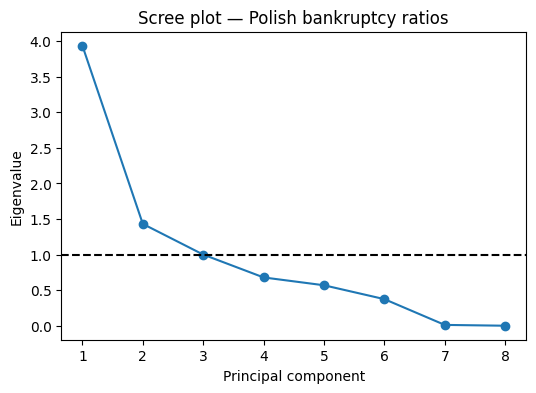

In [4]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(variables)+1), eigenvalues, marker="o")  # eigenvalue per component, in order
plt.axhline(1, color="black", linestyle="--")                  # Kaiser cutoff reference line
plt.xlabel("Principal component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot — Polish bankruptcy ratios")
plt.show()

**What to look for:**
- The point where the curve "elbows" (flattens out) suggests where extra components stop adding much.
- Components above the dashed line (eigenvalue > 1) are the Kaiser-rule candidates to retain.

*(Write down here how many PCs you decide to retain and why, once you run the plot on the real data.)*

## 4. Reading the loadings

The **loading table** shows the weights $w_{kj}$ from the equation in Step 2 — one column per component, one row per ratio.

**How to read a loading:**
- **Large absolute value** → that ratio contributes strongly to the component.
- **Positive loading** → the ratio moves in the *same* direction as the component score.
- **Negative loading** → the ratio moves in the *opposite* direction.
- **Close to zero** → the ratio contributes little to that component.
- Interpret a component from **several** of its strongest loadings, not from a single variable.
- **The sign of a whole component is arbitrary** — flipping every sign on a PC does not change its meaning, only its direction. Focus on the *pattern* and the *relative* directions of the ratios.

**Worked example (from the TA guide):** suppose PC1 loads strongly positive on X1 (profit/assets), X6 or X8 (retained earnings / equity strength), but strongly **negative** on X2 (liabilities/assets). Firms with a *high* PC1 score are profitable and comparatively unleveraged; firms with a *low* PC1 score lean loss-making and highly indebted. A reasonable label: **"financial strength / profitability relative to leverage."**

In [5]:
loadings = pd.DataFrame(
    pca.components_.T,                                    # transpose: rows = variables, cols = components
    index=variables,
    columns=[f"PC{i}" for i in range(1, len(variables)+1)]
)
loadings.round(2)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
X1,0.32,0.00,-0.02,-0.93,0.02,-0.16,0.02,-0.00
X2,0.49,0.00,0.00,0.13,-0.00,0.27,0.44,0.69
X3,-0.49,-0.00,-0.00,-0.11,-0.00,-0.28,0.82,-0.04
X4,-0.00,0.71,0.01,-0.01,-0.71,0.01,-0.00,0.00
X6,-0.41,-0.00,-0.01,-0.29,0.01,0.87,0.01,0.00
X8,-0.00,0.71,0.00,0.01,0.71,-0.00,0.00,-0.00
X9,0.00,-0.01,1.00,-0.02,0.00,-0.00,0.00,-0.00
X10,-0.49,-0.00,-0.00,-0.13,0.00,-0.27,-0.38,0.72


### Your task
For each retained PC (from your scree-plot decision in Step 3):
1. List its 2–3 strongest absolute loadings (positive and negative).
2. Propose a short, cautious financial label (e.g., *"profitability vs. leverage"*).
3. Sanity-check the sign logic: does a *high* score on this PC make financial sense given the ratios involved?

## 5. What can we do with the PC scores next?

Once each firm has a small set of PC scores instead of 8 correlated ratios, those scores become compact, uncorrelated inputs for further analysis. Common next uses:

- **Regression / logistic regression** predictors (e.g., predicting bankruptcy) instead of using 8 collinear ratios directly.
- **Clustering** firms using PC1 and PC2 instead of many correlated ratios (this is exactly what feeds into the earlier clustering tutorial).
- **Visualization**: plotting firms on the PC1–PC2 plane to see how they spread out.
- **Compact financial profiles / dashboards**: summarizing a firm's financial position in 2–3 numbers instead of dozens.

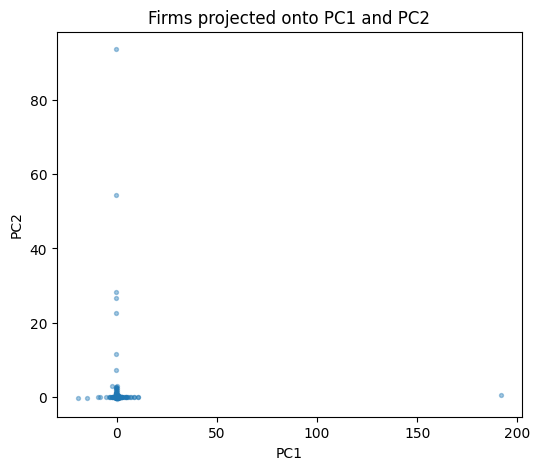

In [6]:
import numpy as np

scores_df = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])  # keep first two PC scores per firm

plt.figure(figsize=(6,5))
plt.scatter(scores_df["PC1"], scores_df["PC2"], s=8, alpha=0.4)  # each dot = one firm on the PC1-PC2 plane
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Firms projected onto PC1 and PC2")
plt.show()

## Wrap-up questions

1. How many components did you retain, and why?
2. Write a one-sentence financial label for each retained component, grounded in its strongest loadings.
3. If you standardized differently (say, using min-max scaling instead of z-scores), would you expect the *same* components? Why or why not?
4. Name one downstream analysis (regression, clustering, ...) where you would use these PC scores instead of the original 8 ratios, and why that helps.